In [59]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

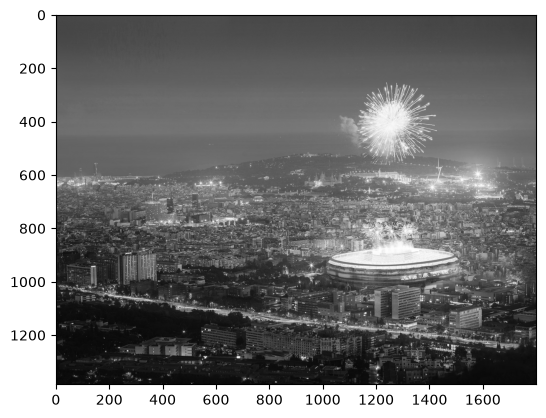

In [60]:
image = cv2.imread('camp_nou.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
plt.imshow(image_gray, cmap="gray")

Гаусс

In [61]:
mean = 0
stddev = 189
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,   0, 255, ...,   0,   0,   0],
       [  0,  80, 255, ...,   0,  56,  15],
       [  0,   0,   0, ...,   0,   6,   0],
       ...,
       [  0,   0,  94, ...,   0, 215,   8],
       [  0,   0,   0, ..., 100, 188, 254],
       [255,   0,  19, ...,  91, 129,   0]],
      shape=(1385, 1800), dtype=uint8)

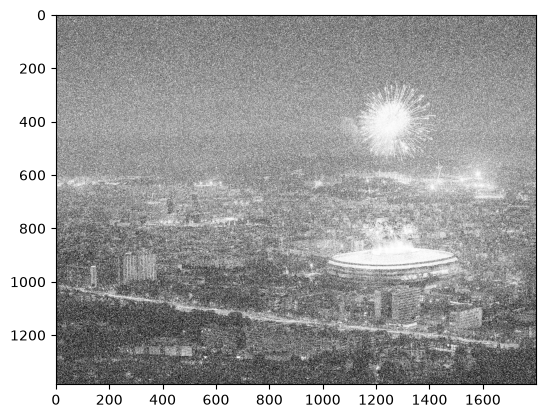

In [62]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

Постоянный

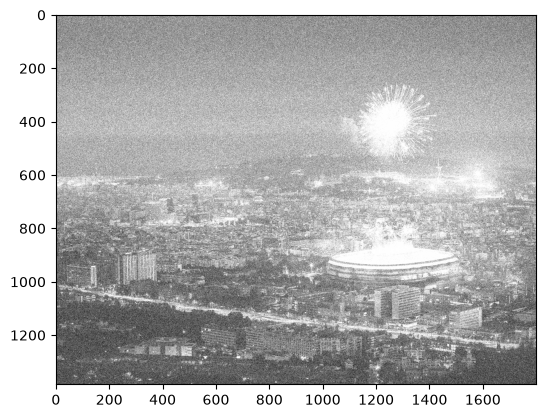

In [63]:
a = 0
b = 150
noise_uniform = np.random.uniform(a, b, image_gray.shape)
image_noise_uniform = image_gray.astype(np.float32) + noise_uniform
image_noise_uniform = np.clip(image_noise_uniform, 0, 255).astype(np.uint8)
plt.imshow(image_noise_uniform, cmap="gray")

Медианный фильтр

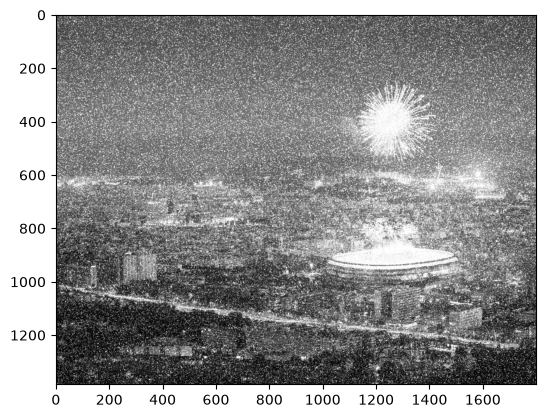

In [64]:
image_noise_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
plt.imshow(image_noise_gauss_median, cmap="gray")

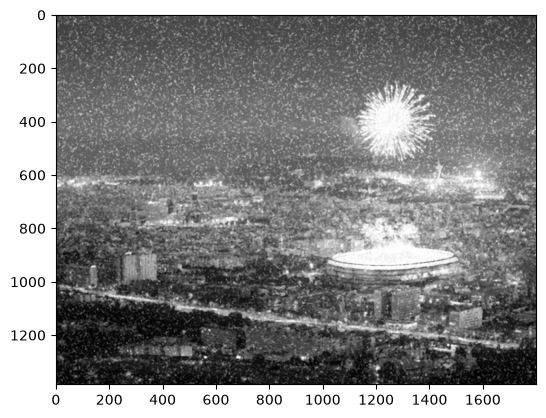

In [65]:
image_noise_gauss_median = cv2.medianBlur(image_noise_gauss, 7)
plt.imshow(image_noise_gauss_median, cmap="gray")

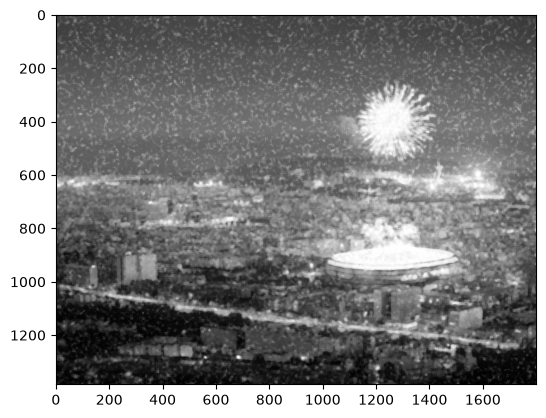

In [66]:
image_noise_gauss_median = cv2.medianBlur(image_noise_gauss, 11)
plt.imshow(image_noise_gauss_median, cmap="gray")

Фильтр Гаусса

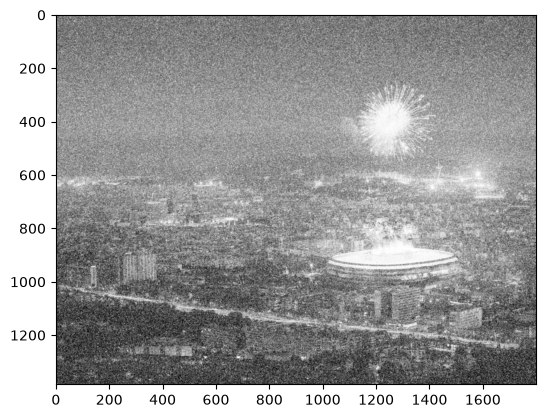

In [67]:
image_noise_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)
plt.imshow(image_noise_gauss_gauss, cmap="gray")

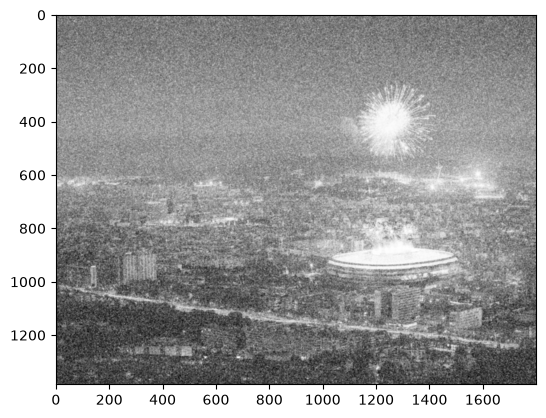

In [68]:
image_noise_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),3)
plt.imshow(image_noise_gauss_gauss, cmap="gray")

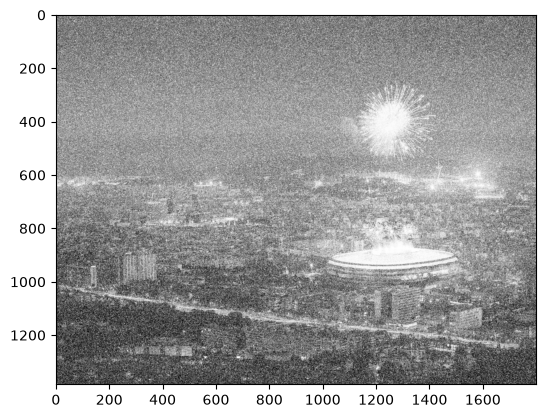

In [69]:
image_noise_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(3,3),0)
plt.imshow(image_noise_gauss_gauss, cmap="gray")

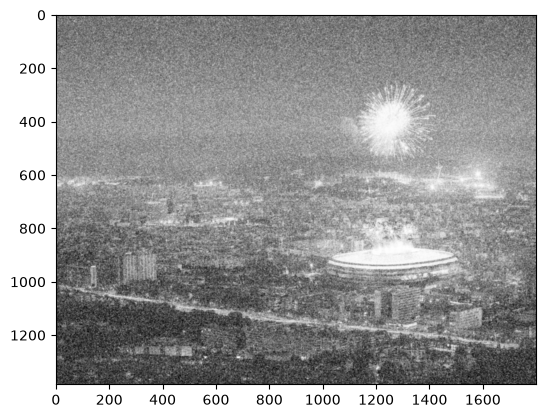

In [70]:
image_noise_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(7,7),0)
plt.imshow(image_noise_gauss_gauss, cmap="gray")

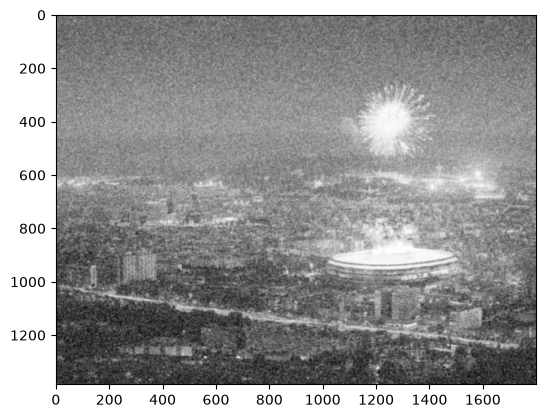

In [71]:
image_noise_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(11,11),0)
plt.imshow(image_noise_gauss_gauss, cmap="gray")

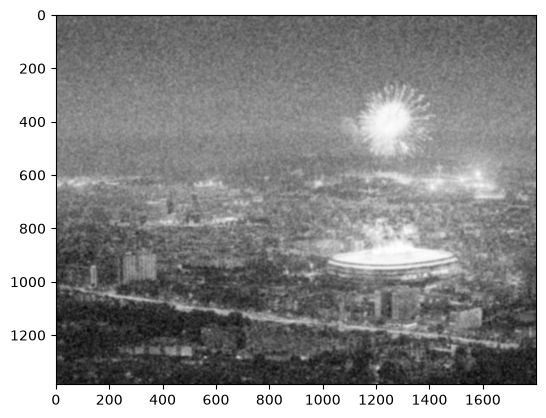

In [72]:
image_noise_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(19,19),0)
plt.imshow(image_noise_gauss_gauss, cmap="gray")

Билатеральный фильтр

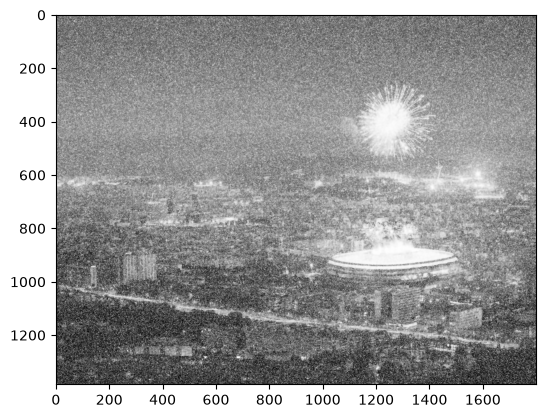

In [73]:
image_noise_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)
plt.imshow(image_noise_gauss_bilat, cmap="gray")

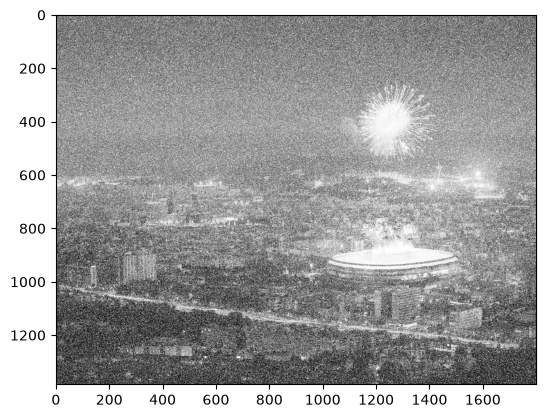

In [74]:
image_noise_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,25,25)
plt.imshow(image_noise_gauss_bilat, cmap="gray")

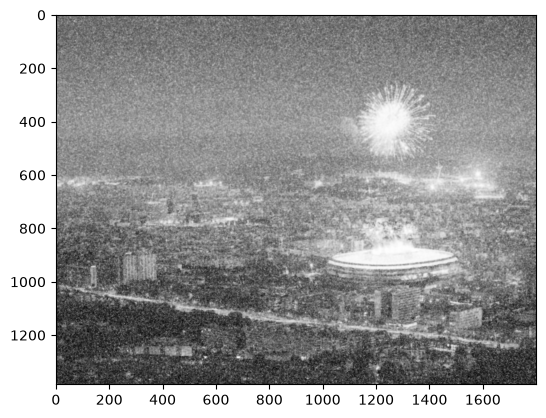

In [75]:
image_noise_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,125,125)
plt.imshow(image_noise_gauss_bilat, cmap="gray")

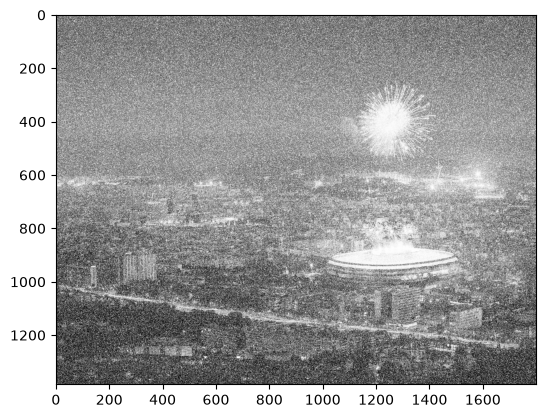

In [76]:
image_noise_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,3,75,75)
plt.imshow(image_noise_gauss_bilat, cmap="gray")

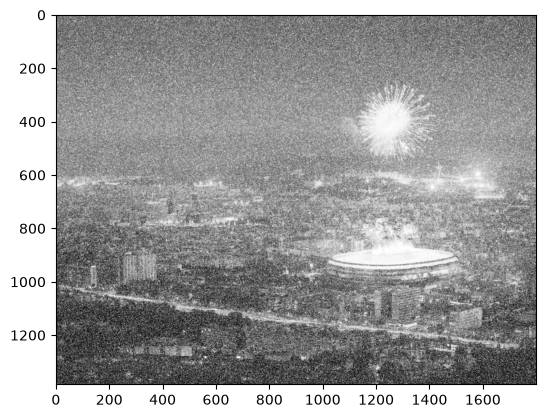

In [77]:
image_noise_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,7,75,75)
plt.imshow(image_noise_gauss_bilat, cmap="gray")

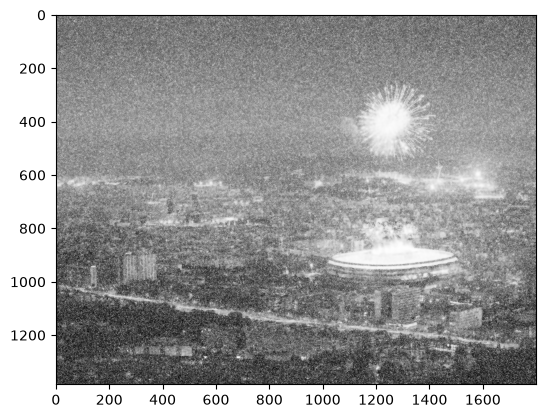

In [78]:
image_noise_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,11,75,75)
plt.imshow(image_noise_gauss_bilat, cmap="gray")

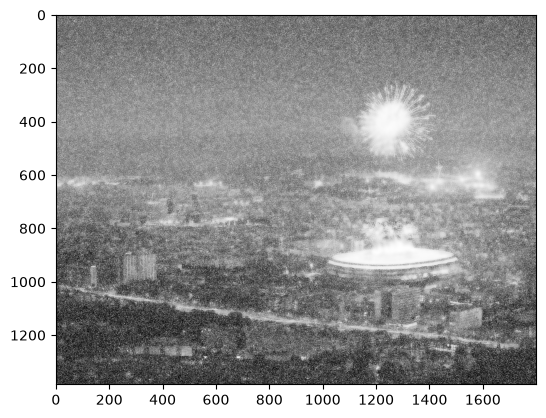

In [79]:
image_noise_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,19,75,75)
plt.imshow(image_noise_gauss_bilat, cmap="gray")

Фильтр нелокальных средних

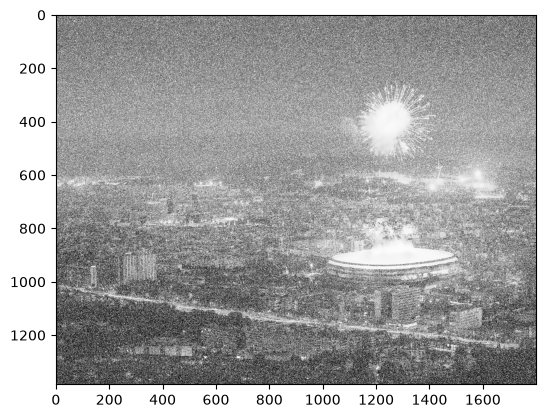

In [80]:
image_noise_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
plt.imshow(image_noise_gauss_nlm, cmap="gray")

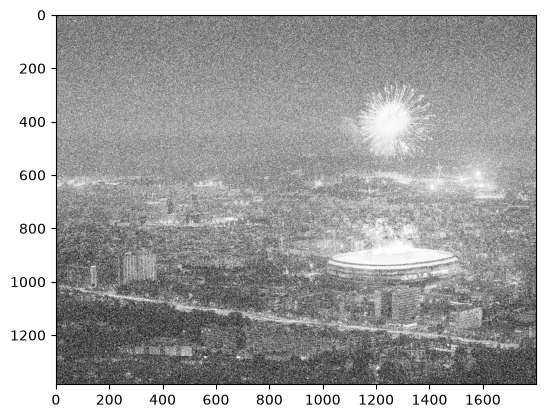

In [81]:
image_noise_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 5)
plt.imshow(image_noise_gauss_nlm, cmap="gray")

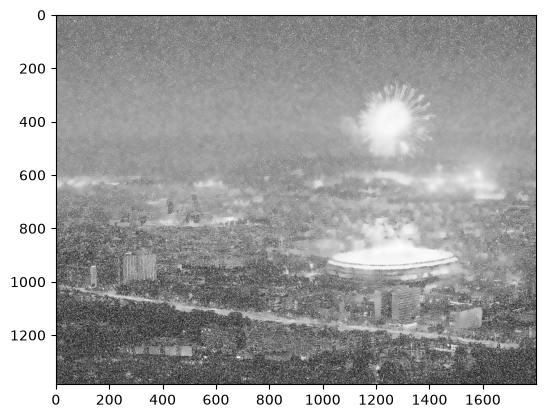

In [82]:
image_noise_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 40)
plt.imshow(image_noise_gauss_nlm, cmap="gray")

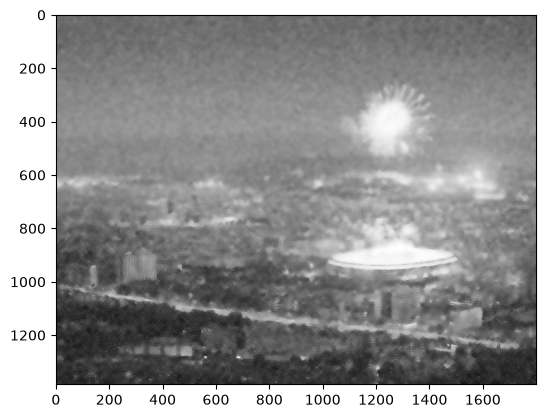

In [83]:
image_noise_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 60)
plt.imshow(image_noise_gauss_nlm, cmap="gray")

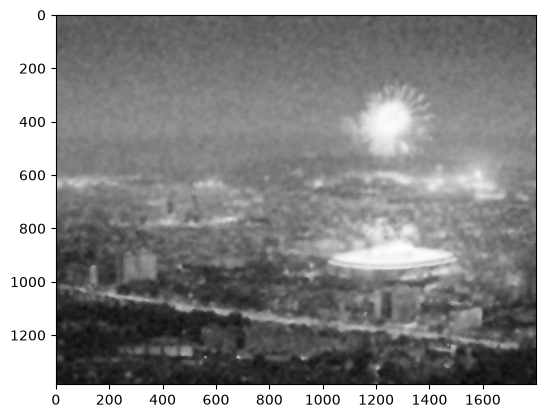

In [84]:
image_noise_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 80)
plt.imshow(image_noise_gauss_nlm, cmap="gray")

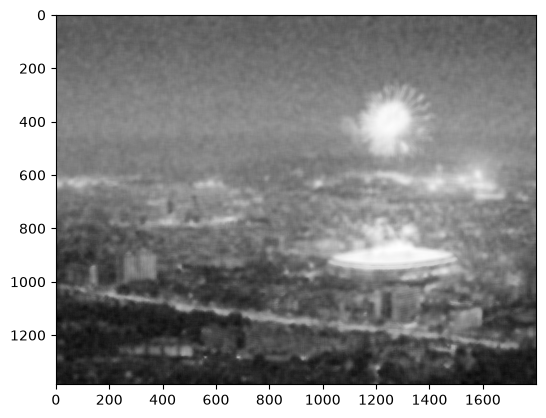

In [85]:
image_noise_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 100)
plt.imshow(image_noise_gauss_nlm, cmap="gray")

Сравнение фильтров

In [86]:
image_noise_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
image_noise_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)
image_noise_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)
image_noise_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

In [87]:
from skimage.metrics import structural_similarity, mean_squared_error
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

7696.143501403931 0.10391475410065344


In [88]:
mse_gauss_median = mean_squared_error(image_gray, image_noise_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_noise_gauss_median, full=True)
print(mse_gauss_median, ssim_gauss_median)

2887.3709843561974 0.17160539423644813


In [89]:
mse_gauss_gauss = mean_squared_error(image_gray, image_noise_gauss_gauss)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray,  image_noise_gauss_gauss, full=True)
print(mse_gauss_gauss, ssim_gauss_gauss)

3495.0090044123544 0.2742266193200459


In [90]:
mse_gauss_bilat = mean_squared_error(image_gray, image_noise_gauss_bilat)
(ssim_gauss_bilat, diff) = structural_similarity(image_gray,  image_noise_gauss_bilat, full=True)
print(mse_gauss_bilat, ssim_gauss_bilat)

4811.178098676293 0.1356051658445283


In [91]:
mse_gauss_nlm = mean_squared_error(image_gray, image_noise_gauss_nlm)
(ssim_gauss_nlm, diff) = structural_similarity(image_gray,  image_noise_gauss_nlm, full=True)
print(mse_gauss_nlm, ssim_gauss_nlm)

7690.375456077016 0.10389840850225865


Видим, что для гауссовского шума лучший фильтр по MSE - медианный,  а по SSIM - Гаусса

Теперь проверим постоянный шум

In [92]:
image_noise_uniform_median = cv2.medianBlur(image_noise_uniform, 3)
image_noise_uniform_gauss = cv2.GaussianBlur(image_noise_uniform,(5,5),0)
image_noise_uniform_bilat = cv2.bilateralFilter(image_noise_uniform,9,75,75)
image_noise_uniform_nlm = cv2.fastNlMeansDenoising(image_noise_uniform, h = 20)

In [93]:
mse_uniform = mean_squared_error(image_gray, image_noise_uniform)
(ssim, diff) = structural_similarity(image_gray, image_noise_uniform, full=True)
print(mse_uniform, ssim)

6966.241436421981 0.16405790903184092


In [94]:
mse_uniform_median = mean_squared_error(image_gray, image_noise_uniform_median)
(ssim_uniform_median, diff) = structural_similarity(image_gray,  image_noise_uniform_median, full=True)
print(mse_uniform_median, ssim_uniform_median)

5947.671446851184 0.23019701685254032


In [95]:
mse_uniform_gauss = mean_squared_error(image_gray, image_noise_uniform_gauss)
(ssim_uniform_gauss, diff) = structural_similarity(image_gray,  image_noise_uniform_gauss, full=True)
print(mse_uniform_gauss, ssim_uniform_gauss)

5492.158742880064 0.36993090486833896


In [96]:
mse_uniform_bilat = mean_squared_error(image_gray, image_noise_uniform_bilat)
(ssim_uniform_bilat, diff) = structural_similarity(image_gray,  image_noise_uniform_bilat, full=True)
print(mse_uniform_bilat, ssim_uniform_bilat)

5596.8275066185315 0.30279435993479703


In [97]:
mse_uniform_nlm = mean_squared_error(image_gray, image_noise_uniform_nlm)
(ssim_uniform_nlm, diff) = structural_similarity(image_gray,  image_noise_uniform_nlm, full=True)
print(mse_uniform_nlm, ssim_uniform_nlm)

6895.482066185319 0.16384288405100417


Видим, что для постоянного шума и по MSE, и по SSIM лучшим фильтром является фильтр Гаусса